# Setup

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import pickle
import math
from time import time
from statistics import median


from dimod import ConstrainedQuadraticModel, BinaryQuadraticModel, Binary, quicksum
from dwave.system import LeapHybridCQMSampler
from dwave.samplers import SimulatedAnnealingSampler

data_folder = "../../data/"
raw_data_folder = data_folder+"raw/"
formatted_data_folder = data_folder+"formatted/"
model_folder = "../../models/"
figure_folder = "../../reports/figures/"

project_title = "CA Fire Separation - Subset"

In [5]:
### Functions ###

# --------------------------------------------
# "ORIGINAL" D-WAVE FUNCTIONS
# --------------------------------------------


# Original function for building constrained quadratic model
def build_cqm(G, timed=False):
    """ Build the CQM for the problem instance."""
    start = time()
    # Two groups (cases 0, 1) and one separator group (case 2)
    num_groups = 3

    # Initialize the CQM object
    print("\nBuilding CQM...")
    cqm = ConstrainedQuadraticModel()

    # Build the CQM starting by creating variables
    vars = [[Binary(f'x_{name}_{i}') for i in range(num_groups)] for name in G.nodes()]

    # Set objective for CQM
    cqm.set_objective(quicksum(vars[i][2] for i in range(len(vars))))

    # Add constraint to make variables discrete
    # for v in range(len(vars)):
    for v in G.nodes():
        cqm.add_discrete([f'x_{v}_{i}' for i in range(num_groups)])

    # Add constraint to CQM: |G1|=|G2|
    g1 = [vars[i][0] for i in range(len(vars))]
    g2 = [vars[i][1] for i in range(len(vars))]
    cqm.add_constraint(quicksum(g1) - quicksum(g2) <= 1)
    cqm.add_constraint(quicksum(g1) - quicksum(g2) >= -1)

    # Add constraint to CQM: e(G1, G2) = 0
    node2ind = {n:i for i,n in enumerate(G.nodes())}
    edge_sum = []
    for a, b in G.edges():
        if a != b:
            edge_sum.append(vars[node2ind[a]][0]*vars[node2ind[b]][1]+vars[node2ind[a]][1]*vars[node2ind[b]][0])
    cqm.add_constraint(quicksum(edge_sum) == 0, label='cross edges')
    end = time()
    
    if timed:
        building_time = end - start
        return cqm, building_time
    
    else:
        return cqm

def run_cqm_and_collect_solutions(cqm, sampler, timed=False, time_limit=None):
    """ Send the CQM to the sampler and return the best sample found."""
    
    ## Initialize the solver
    print("\nSending to the solver...")
    
    start = time()
    ## Solve the CQM problem using the solver
    sampleset = sampler.sample_cqm(cqm, label=project_title, time_limit=time_limit)
    sampleset_info = sampleset.info
    print("\nSampleset Information:")
    print(sampleset_info)
    print("\n")
    sampleset.resolve()
    end = time()

    ## Get the first feasible solution
    feasible_sampleset = sampleset.filter(lambda d: d.is_feasible)
    if len(feasible_sampleset) == 0:
        print("\nNo feasible solution found. Returning best infeasible solution.")
        sample = sampleset.first.sample

    else:
        sample = feasible_sampleset.first.sample
    
    if timed:
        solver_time = end - start
        return sample, sampleset_info, solver_time
    else:
        return sample, sampleset_info

def process_sample(G, sample, timed = False):
    """ Interpret the CQM solution in terms of the partitioning problem."""
    start = time()
    # Display results to user
    group_1 = []
    group_2 = []
    sep_group = []
    results = [[],[],[]]
    for key, val in sample.items(): # key is of form "x_{node}_{group #}" and val is 0 or 1
        if val == 1:
            v = key.split("_")
            results[int(v[-1])].append(int(v[1]))

    group_1 = results[0]
    group_2 = results[1]
    sep_group = results[2]

    # Display best result
    print("\nPartition Found:")
    print("\tGroup 1: \tSize", len(group_1))
    print("\tGroup 2: \tSize", len(group_2))
    print("\tSeparator: \tSize", len(sep_group))

    print("\nSeparator Fraction: \t", len(sep_group)/len(G.nodes()))

    # Determines if there are any edges directly between the large groups
    illegal_edges = [(u, v) for u, v in G.edges if (sample[f'x_{u}_{0}']*sample[f'x_{v}_{1}'] == 1 or sample[f'x_{u}_{1}']*sample[f'x_{v}_{0}'] == 1)]

    print("\nNumber of illegal edges:\t", len(illegal_edges))
    end = time()
    
    if timed:
        sample_process_time = end - start
        return group_1, group_2, sep_group, illegal_edges, sample_process_time
    else:
        return group_1, group_2, sep_group, illegal_edges

# def visualize_results(G, group_1, group_2, illegal_edges, save = False):
#     """ Visualize the partition."""

#     print("\nVisualizing output...")

#     G1 = G.subgraph(group_1)
#     G2 = G.subgraph(group_2)

#     pos_1 = nx.random_layout(G1, center=(-5,0))
#     pos_2 = nx.random_layout(G2, center=(5,0))
#     pos = {**pos_1, **pos_2}

#     nx.draw_networkx_nodes(G, pos_1, node_size=10, nodelist=group_1, node_color='#17bebb', edgecolors='k')
#     nx.draw_networkx_nodes(G, pos_2, node_size=10, nodelist=group_2, node_color='#2a7de1', edgecolors='k')

#     nx.draw_networkx_edges(G, pos, edgelist=G.edges(), style='solid', edge_color='#808080')
#     nx.draw_networkx_edges(G, pos, edgelist=illegal_edges, style='solid')

#     # plt.draw()
#     if save:
#         output_name = 'separator.png'
#         plt.savefig(output_name)
#         print("\tOutput stored in", output_name)
#     plt.show()
#     # plt.close()

def visualize_groups(G, pos, group_1, group_2, illegal_edges, sep_group=[], noise = False, save = False, filename = None):
    '''
    Visualize the groups using their original positions.
    noise parameter slightly changes the positions to make
    it easier to see edges if nodes are orginally arranged
    in a regular pattern, like a rectangular grid.
    '''
    
    ## Identify non-isolated nodes
    isolated_nodes = list(nx.isolates(G))
    non_isolated_nodes = [node for node in G.nodes if node not in isolated_nodes]
    
    if noise:
        mu = 0.08/(len(G.nodes) - 1)
        pos = {key: (val[0] + mu*np.random.randn(), val[1] + mu*np.random.randn()) for key,val in pos.items()}
    
    ## Make layout from known positions
    pos = nx.spring_layout(G, pos=pos, fixed=[i for i in pos.keys()])
    
    ## Make lists for non-isolated nodes
    G1 = [node for node in group_1 if node in non_isolated_nodes]
    G2 = [node for node in group_2 if node in non_isolated_nodes]
    S = [node for node in sep_group if node in non_isolated_nodes]
    
    fig = plt.figure()
    
    c1 = 'lime' #'#17bebb'
    c2 = 'cornflowerblue' #'#2a7de1'
    cs = '#ffab0f' #'#f37820'
    
    ## Draw nodes
    nx.draw_networkx_nodes(G, pos=pos, node_size=10, nodelist=G1, node_color=c1, edgecolors='k')
    nx.draw_networkx_nodes(G, pos=pos, node_size=10, nodelist=G2, node_color=c2, edgecolors='k')
    nx.draw_networkx_nodes(G, pos=pos, node_size=15, nodelist=S, node_color=cs, edgecolors='k')
    
    ## Draw edges
    nx.draw_networkx_edges(G, pos=pos, nodelist=non_isolated_nodes, style='solid', edge_color='#808080')
    nx.draw_networkx_edges(G, pos, edgelist=illegal_edges, style='solid', edge_color='red')
    
    ## Create legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', label='Group 1',markerfacecolor=c1, markeredgecolor='k', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', label='Group 2',markerfacecolor=c2, markeredgecolor='k', markersize=10)
    ]
    if len(sep_group)>0:
        legend_elements += [plt.Line2D([0], [0], marker='o', color='w', label='Separator',markerfacecolor=cs, markeredgecolor='k', markersize=10)] 
        
    legend_elements += [plt.Line2D([0], [0], color='red', label='Cross-edge')]

    plt.legend(handles=legend_elements)
    
    ## Save results
    if save:
        if filename is None:
            output_name = figure_folder+'groups.png'
        else:
            output_name = figure_folder+filename
        plt.savefig(output_name)
        print("\nOutput stored in", output_name)
    
    plt.show()
    # return fig  

def visualize_results(G, group_1, group_2, sep_group, illegal_edges, save = False, filename = None):
    """ 
    Visualize the partition.
    Based on code from D-Wave.
    """

    print("\nVisualizing output...")

    G1 = G.subgraph(group_1)
    G2 = G.subgraph(group_2)
    SG = G.subgraph(sep_group)

    pos_1 = nx.random_layout(G1, center=(-5,0))
    pos_2 = nx.random_layout(G2, center=(5,0))
    pos_sep = nx.random_layout(SG, center=(0,0))
    pos = {**pos_1, **pos_2, **pos_sep}

    nx.draw_networkx_nodes(G, pos_1, node_size=10, nodelist=group_1, node_color='#17bebb', edgecolors='k')
    nx.draw_networkx_nodes(G, pos_2, node_size=10, nodelist=group_2, node_color='#2a7de1', edgecolors='k')
    nx.draw_networkx_nodes(G, pos_sep, node_size=10, nodelist=sep_group, node_color='#f37820', edgecolors='k')

    nx.draw_networkx_edges(G, pos, edgelist=G.edges(), style='solid', edge_color='#808080')
    nx.draw_networkx_edges(G, pos, edgelist=illegal_edges, style='solid')

    # plt.draw()
    if save:
        if filename is None:
            output_name = figure_folder+'separator.png'
        else:
            output_name = figure_folder+filename
        plt.savefig(output_name)
        print("\tOutput stored in", output_name)
    plt.show()
    # plt.close()

## Graphs

In [7]:
### Load data for fire graph

with open(formatted_data_folder+'fire_centroids_3.pkl', 'rb') as handle:
    centroids = pickle.load(handle)

with open(formatted_data_folder+'fire_graph_3.pkl', 'rb') as handle:
    G = pickle.load(handle)

In [8]:
print(len(G.nodes()),len(G.edges))

1695 4212


In [9]:
# Identify and remove isolated nodes
isolated = list(nx.isolates(G))
print("Isolated nodes:", isolated)

# Remove corresponding centroids and nodes
for i in sorted(isolated)[::-1]:
    centroids.pop(i)
G.remove_nodes_from(isolated)
print("Nodes removed")
# Re-label nodes
G = nx.convert_node_labels_to_integers(G, ordering='sorted')

Isolated nodes: [113, 118, 213, 327, 362, 387, 420, 443, 448, 488, 491, 493, 573, 653, 691, 692, 730, 777, 858, 859, 1072, 1103, 1185, 1248, 1298, 1481, 1526, 1585, 1614, 1637, 1674, 1686]
Nodes removed


In [27]:
print(len(centroids),len(G.nodes()))

1663 1663


Nodes: 1663 	Edges: 4212


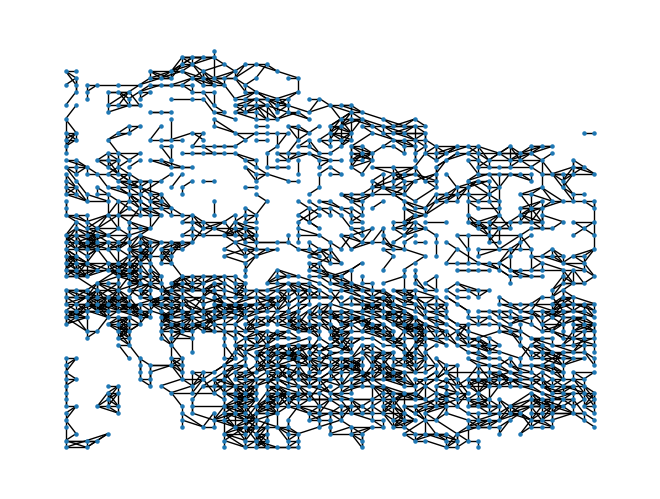

In [28]:
## Show networkx graph with coordinate positions

positions = [(centroid.x, centroid.y) for centroid in centroids]
pos = {node: coords for node, coords in zip(list(G.nodes()),positions)}
print("Nodes:",len(G.nodes), "\tEdges:",len(G.edges))
nx.draw(G, pos, node_size = 5)

Nodes: 267
Variables: ~801


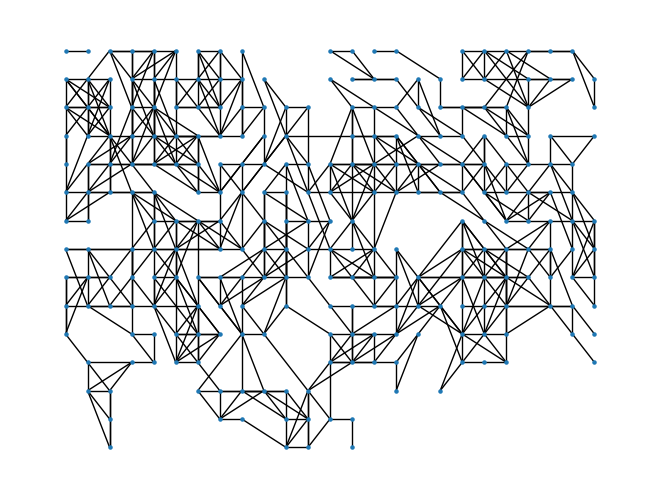

In [29]:
## Subset to lower right portion of the graph, 1/8th of original area

xlist, ylist = zip(*positions)
xlist = list(xlist)
ylist = list(ylist)
xmax = max(xlist)
xmin = min(xlist)
ymax = max(ylist)
ymin = min(ylist)
xmid = (xmax+xmin)/2
ymid = (ymax+3*ymin)/4

sub_nodes = [node for node in G.nodes if (pos[node][0] > xmid and pos[node][1] < ymid)]
sub_edges = [edge for edge in G.edges if (edge[0] in sub_nodes and edge[1] in sub_nodes)]

G = nx.Graph(sub_edges)
print(f"Nodes: {len(G.nodes)}")
print(f"Variables: ~{3*len(G.nodes)}")
nx.draw(G, pos, node_size = 5)

# Run solver

In [10]:
hybrid_results = {}
timing_info = {}

In [11]:
## Build model with separation constraint
cqm, building_time = build_cqm(G,timed=True)
timing_info['building_time'] = building_time

## Setup sampler
sampler = LeapHybridCQMSampler()
## Retrieve minimum time limit required
min_time_limit = sampler.min_time_limit(cqm)
print(f"Minimum time limit: {min_time_limit}")
timing_info['min_time_limit'] = min_time_limit


Building CQM...
Minimum time limit: 5


In [35]:
## Run trials for optimization
time_limit = math.ceil(min_time_limit)
timing_info['time_limit'] = time_limit
## If requested time limit is too low, raise an error
if time_limit < min_time_limit:
    raise Exception(f"Minimum time limit is {min_time_limit}, asked to use time limit {time_limit}")
    
## Restart sampler
sampler = LeapHybridCQMSampler()
## Run solver: this is where time on solver is used
sample, sampleset_info, solver_time = run_cqm_and_collect_solutions(cqm, sampler, timed=True, time_limit = time_limit)
print("Solver Time (with latency):",solver_time)
timing_info['solver_time'] = solver_time
hybrid_results['sampleset_info'] = sampleset_info


## Process results into classification groups and illegal edges
group_1, group_2, sep_group, illegal_edges, sample_process_time = process_sample(G, sample, timed=True)
timing_info['sample_process_time'] = sample_process_time
hybrid_results['group_1'] = group_1
hybrid_results['group_2'] = group_2
hybrid_results['sep_group'] = sep_group
hybrid_results['illegal_edges'] = illegal_edges

hybrid_results['timing_info'] = timing_info

Solver Time (with latency): 9.348122119903564

Partition Found:
	Group 1: 	Size 130
	Group 2: 	Size 130
	Separator: 	Size 7

Separator Fraction: 	 0.026217228464419477

Number of illegal edges:	 0


In [37]:
## Save results
with open(model_folder+'hybrid_results.pkl', 'wb') as handle:
    pickle.dump(hybrid_results, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
## Load results
with open(model_folder+'hybrid_results.pkl', 'rb') as handle:
    results = pickle.load(handle)

# Visualize Results

In [38]:
mydict = hybrid_results
group_1 = mydict['group_1']
group_2 = mydict['group_2']
illegal_edges = mydict['illegal_edges']
sep_group = mydict['sep_group']


Visualizing output...
	Output stored in ../../reports/figures/hybrid_separated_network.png


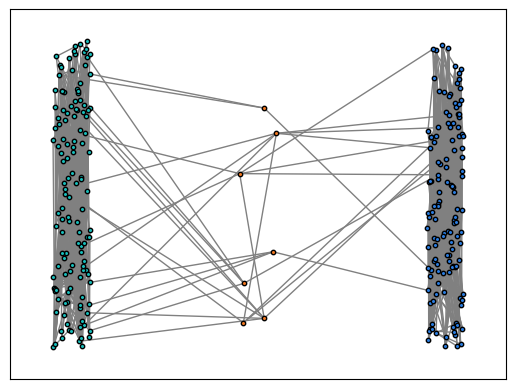

In [40]:
visualize_results(G,group_1,group_2,sep_group,illegal_edges, save=True, filename="hybrid_separated_network.png")


Output stored in ../../reports/figures/hybrid_groups.png


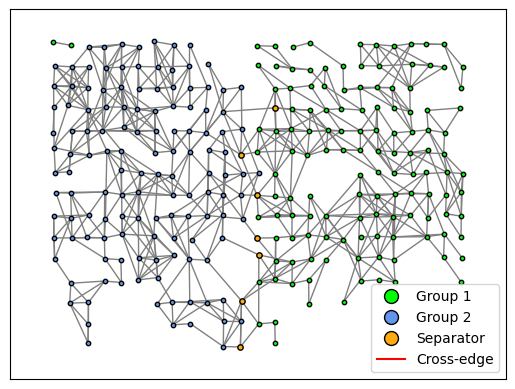

In [41]:
visualize_groups(G, pos, group_1, group_2, illegal_edges, sep_group, noise=True, save=True, filename = "hybrid_groups.png")